In [1]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    EsmConfig,
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

from sklearn.linear_model import LinearRegression

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

# Load CovFit model

In [4]:
TOK_DIR = "./covfit_stuff/Tokenizer"
CONF_DIR = "./covfit_stuff/Config"
TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt"
FOLD_ID = 0
N_TARGETS = 1565
MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt"

In [5]:
# MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
# FOLD_IDS_TO_USE = [0]
# TARGET_FOLD_ID = 0
# OUTPUT_PREFIX = "inference_results"

model_name = "facebook/esm2_t33_650M_UR50D"
device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [6]:
def get_model(
    TOK_DIR = "./covfit_stuff/Tokenizer",
    CONF_DIR = "./covfit_stuff/Config",
    TASK_IDS_FILE = "./covfit_stuff/task_id_dict.pt",
    FOLD_ID = 0,
    N_TARGETS = 1565,
    MODEL_PATH = f"./covfit_stuff/models/covfit_model_20241007_{FOLD_ID}.ckpt",
    device=device
):
    esm_config = EsmConfig.from_pretrained(CONF_DIR)
    model = EsmForRegression(esm_config, N_TARGETS).to(device)

    lora_config = LoraConfig(
        task_type="SEQ_CLS",
        r=8,
        lora_alpha=16,
        target_modules=["key", "query", "value","dense"],
        lora_dropout=0.05,
        bias="lora_only",
        modules_to_save=["regressor"]
    )
    esm_fine_tuned = get_peft_model(model, lora_config)
    state_dict = torch.load(MODEL_PATH, map_location=device)
    
    # keys_to_remove = []
    # for key in state_dict.keys():
    #     if 'contact_head' in key:
    #         keys_to_remove.append(key)
    
    # for key in keys_to_remove:
    #     del state_dict[key]

    wrong_keys = [key for key in state_dict.keys() if key not in esm_fine_tuned.state_dict().keys()]
    key_list = list(state_dict.keys())
    for key in key_list:
        if key in wrong_keys:
            correct_key = key.rsplit('.',1)[0]+'.base_layer.'+key.rsplit('.',1)[1]
            state_dict[correct_key] = state_dict.pop(key)

    del state_dict["base_model.model.esm.embeddings.position_embeddings.base_layer.weight"]
    
    esm_fine_tuned.load_state_dict(state_dict)
    esm_fine_tuned = esm_fine_tuned.merge_and_unload()
    esm_fine_tuned.eval()
    esm_fine_tuned.esm.embeddings.token_dropout = False

    return esm_fine_tuned

In [7]:
esm_fine_tuned = get_model()

In [8]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [9]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name
REPO_ID = esm_config.model_name
original_task_id_infos = torch.load("./covfit_stuff/task_id_dict.pt", map_location=device)

In [10]:
tokenizer_config = {}
special_tokens_map_file = "./covfit_stuff/Tokenizer/special_tokens_map.json"
tokenizer_config["vocab_file"] = "./covfit_stuff/Tokenizer/vocab.txt"
tokenizer_config["model_max_length"] = CONTEXT_LEN

with open("./covfit_stuff/Tokenizer/special_tokens_map.json", "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [11]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

In [12]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [13]:
# clean up memory
torch.cuda.empty_cache()

# Load Data

In [14]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [15]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [16]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [17]:
"""
uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]
    
    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences 

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences 
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4404
torch.Size([4404, 1024])


In [18]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [19]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [20]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [21]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

In [22]:
logit_id = original_task_id_infos["fitness_USA"]

# Curating new fitness with low-mutation dataset

# L455F mutation

# Is MLP linear?

### This experiment caches \~3500 pairs of L455,F455 seqs. (~7000 seqs total) and sees if the EsmRegressor is simply performing a linear operation on the final outputs

In [25]:
# Making big dataset of L455,F455 seqs. to see if MLP linear
##########################################
# adding data with FLip mutation (L455F)
N=455
L455_seqs = [x for x in all_uniq_seqs if x[N-1] == "L"]
F455_seqs = [x[:N-1] + "F" + x[N:] for x in L455_seqs]

train_seqs = tokenizer([*L455_seqs, *F455_seqs], return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)
print(f"Number unique sequences: {len(L455_seqs) + len(F455_seqs)}")
print(train_seqs.shape)

Number unique sequences: 7148
torch.Size([7148, 1024])


In [26]:
n_data = len(L455_seqs) + len(F455_seqs)
batch = 200

LF_in = torch.empty(train_seqs.shape[0], hooked_esm.cfg.d_model).to(device)
LF_out = torch.empty(train_seqs.shape[0]).to(device)

for i in range(0,n_data,batch):
    print(".",end="")
    esm_output = hooked_esm(train_seqs[i:i+batch]) # get ESM output for seqs. 
    reg_output = get_logit_hooked(esm_output, logit_id) # get fitness score for seqs.

    LF_in[i:(i+batch), :] = esm_output[:,0,:]
    LF_out[i:(i+batch)] = reg_output.squeeze()
    torch.cuda.empty_cache()

print()

....................................


In [27]:
LF_in_numpy = LF_in.cpu().numpy()
LF_out_numpy = LF_out.cpu().numpy()

In [28]:
print(LF_in_numpy.shape)
print(LF_out_numpy.shape)

(7148, 1280)
(7148,)


In [29]:
lin_reg = LinearRegression().fit(LF_in_numpy,LF_out_numpy)
reg_score = lin_reg.score(LF_in_numpy,LF_out_numpy)

In [30]:
lin_reg_outputs = lin_reg.predict(LF_in_numpy)
lin_reg_matrix = lin_reg.coef_
lin_reg_matrix_output = LF_in_numpy @ lin_reg_matrix

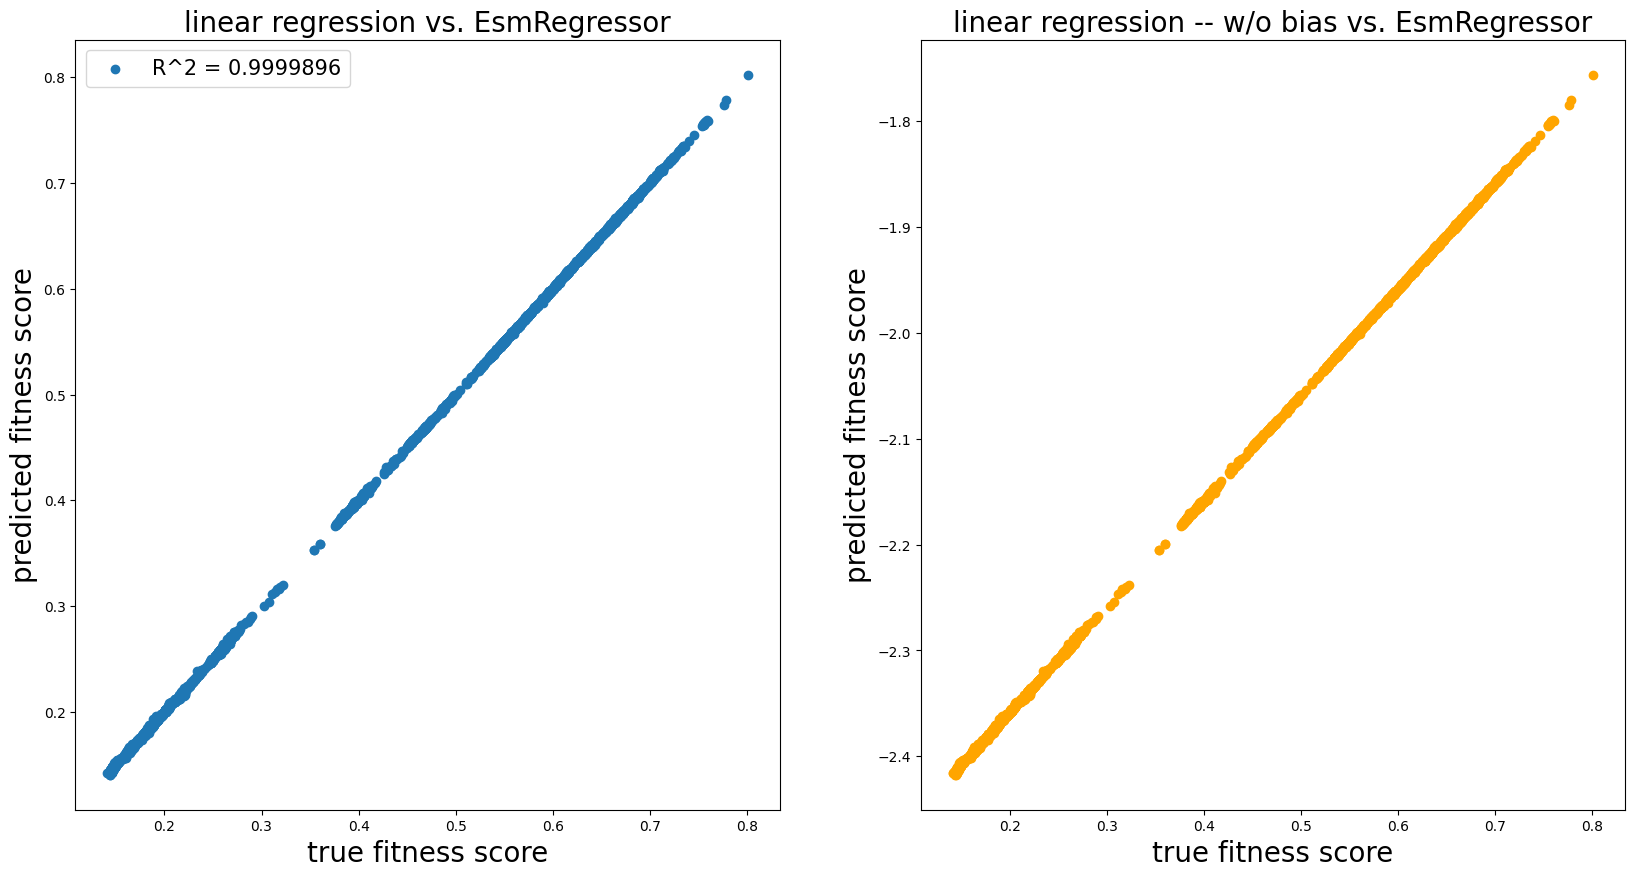

In [31]:
fig, ax = plt.subplots(1,2,figsize=(20,10))
ax[0].set_title("linear regression vs. EsmRegressor", fontsize=20)
ax[0].scatter(LF_out_numpy, lin_reg_outputs, label="R^2 = %.7f"%(reg_score))
ax[0].legend(loc="upper left", fontsize=15)
ax[1].set_title("linear regression -- w/o bias vs. EsmRegressor", fontsize=20)
ax[1].scatter(LF_out_numpy, lin_reg_matrix_output, color="orange")

for a in ax:
    a.set_xlabel("true fitness score", fontsize=20)
    a.set_ylabel("predicted fitness score", fontsize=20)
plt.show()

In [36]:
print(torch.from_numpy(lin_reg_matrix).shape)

torch.Size([1280])


In [70]:
# since the final ESM_regressor is basically just a linear regression, I can freeze the linear regression weights and save them as unembed matrix (useful for marks et al. stuff)
identity_unembed = hooked_esm.W_U
hooked_esm.unembed.W_U = torch.nn.parameter.Parameter(torch.from_numpy(lin_reg_matrix.T)[:,None].to(device).float(), requires_grad=False)
hooked_esm.unembed.b_U = torch.nn.parameter.Parameter(torch.tensor(0).to(device).float(), requires_grad=False)

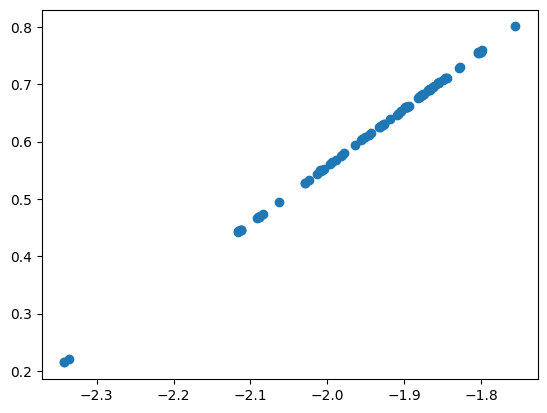

In [71]:
test = hooked_esm(train_seqs[5000:5100])[:,0,0].cpu()
plt.scatter(test, LF_out_numpy[5000:5100])
plt.show()
torch.cuda.empty_cache()

# TODO: marks et al. 
## See metric_fn in ablation.py (line 176)
## used by "_pe_attrib" in attribution.py (line 15), "patching\_effect" (line 224), "get_circuit" in circuit.py (line 40)